# Feature Selection — Phase 2

Queries `features.customer_features` and asks: **of the features that already exist in the matrix, which ones are earning their place?**

See [docs/feature-exploration.md](../docs/feature-exploration.md) for how this fits into the two-phase feature-exploration workflow, and the two automated triggers (consecutive challenger rejections, SHAP rank drift) that recommend running it.

**Prerequisites**
```bash
gcloud auth application-default login
uv sync --all-packages --extra dev
```
`--all-packages` is needed here (not just `--package trainer`) because step 7 imports `post_training.fetch_champion` to pull the production SHAP baseline from Vertex AI Model Registry.

In [16]:
# ── Configuration ────────────────────────────────────────────────────────────
GCP_REGION    = "europe-west1"       # matches training_pipeline.pipeline's default
BQ_TABLE      = "features.customer_features"
SNAPSHOT_DATE = None                  # None = latest partition
SAMPLE_LIMIT  = 20_000

In [17]:
import google.auth
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from google.cloud import bigquery
from ml_common.config import MODEL_DISPLAY_NAME, RANDOM_STATE, TEST_SIZE
from ml_common.preprocess import CATEGORICAL_COLS, prepare_features
from modeling.train import train_model
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

# picked up from the active `gcloud auth application-default login` / `gcloud config set project` context
_, GCP_PROJECT = google.auth.default()
print(f"ml_common / modeling imports OK — using GCP project: {GCP_PROJECT}")

ml_common / modeling imports OK — using GCP project: <your-gcp-project>


## 1. Load data from BigQuery

Same `EXCEPT` pattern the production pipeline uses (`trainer.data.export_snapshot`): `feature_computed_at` and `latest_event_ts` are pipeline metadata, not predictive signals, so they're dropped before they can leak into the model or the EDA below.

In [18]:
bq = bigquery.Client(project=GCP_PROJECT)

date_filter = f"AND snapshot_date = '{SNAPSHOT_DATE}'" if SNAPSHOT_DATE else ""

df = bq.query(f"""
    SELECT * EXCEPT (feature_computed_at, latest_event_ts)
    FROM `{GCP_PROJECT}.{BQ_TABLE}`
    WHERE TRUE {date_filter}
    LIMIT {SAMPLE_LIMIT}
""").to_dataframe()

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
df.head()

Loaded 20,000 rows x 21 columns


,customer_id,membership_tier,region,member_since_days,contact_requests_last_30d,avg_transaction_30d,avg_transaction_90d,payment_failure_rate_30d,payment_failure_rate_90d,total_payment_attempts,...,avg_engagement_30d,avg_engagement_90d,campaign_participation_rate,preferred_channel,total_events,events_last_30d,events_last_90d,renewal_count,churned,snapshot_date
0,fff9754a-e444-428a-9a09-bc8cd721276c,friend,eu-west,3311,1,27.75,27.75,0.0,0.0,4,...,NaN,NaN,1.0,phone,1,1,1,0,False,2026-06-27
1,fff9754a-e444-428a-9a09-bc8cd721276c,friend,eu-west,3311,1,27.75,27.75,0.0,0.0,4,...,NaN,NaN,1.0,phone,1,1,1,0,False,2026-06-26
2,fff8c7c1-529e-4f51-a221-488d7d851de5,guardian,eu-central,665,1,96.62,96.62,0.0,0.0,0,...,0.2128,0.2128,1.0,email,1,1,1,0,True,2026-06-21
3,fff9754a-e444-428a-9a09-bc8cd721276c,friend,eu-west,3311,1,27.75,27.75,0.0,0.0,4,...,NaN,NaN,1.0,phone,1,1,1,0,False,2026-06-28
4,fff9754a-e444-428a-9a09-bc8cd721276c,friend,eu-west,3311,1,27.75,27.75,0.0,0.0,4,...,NaN,NaN,1.0,phone,1,1,1,0,False,2026-06-24


## 2. EDA

Class balance, per-feature distributions, and — critically — *why* a column is missing, not just how much. The generator ([docs/data-lifecycle.md](../docs/data-lifecycle.md)) injects three distinct missingness mechanisms on purpose, so the imputation strategy has to be a deliberate choice rather than a default.

In [19]:
churn_rate = df["churned"].mean()
print(f"Churn rate: {churn_rate:.1%}  ({df['churned'].sum():,} positives / {len(df):,} total)")
df.dtypes

Churn rate: 14.8%  (2,960 positives / 20,000 total)


customer_id                                  str
membership_tier                           str
region                                    str
member_since_days                       Int64
contact_requests_last_30d               Int64
avg_transaction_30d                      float64
avg_transaction_90d                      float64
payment_failure_rate_30d              float64
payment_failure_rate_90d              float64
total_payment_attempts                  Int64
days_since_last_successful_payment      Int64
avg_engagement_30d                    float64
avg_engagement_90d                    float64
campaign_participation_rate           float64
preferred_channel                         str
total_events                            Int64
events_last_30d                         Int64
events_last_90d                         Int64
renewal_count                           Int64
churned                               boolean
snapshot_date                          dbdate
dtype: object

In [20]:
numeric_cols = df.select_dtypes(include="number").columns.drop("churned", errors="ignore")
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
member_since_days,19438.0,1825.282694,1049.754329,1.0,933.0,1823.5,2749.0,3650.0
contact_requests_last_30d,20000.0,0.2954,0.534465,0.0,0.0,0.0,1.0,3.0
avg_transaction_30d,20000.0,42.954873,33.668994,4.84,11.23,28.81,58.5125,136.99
avg_transaction_90d,20000.0,42.954873,33.668994,4.84,11.23,28.81,58.5125,136.99
payment_failure_rate_30d,20000.0,0.242508,0.412889,0.0,0.0,0.0,0.5,1.0
payment_failure_rate_90d,20000.0,0.242508,0.412889,0.0,0.0,0.0,0.5,1.0
total_payment_attempts,20000.0,1.667,1.3677,0.0,1.0,1.0,2.0,10.0
days_since_last_successful_payment,7600.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
avg_engagement_30d,13360.0,0.282822,0.155604,0.003,0.16435,0.2601,0.380362,0.9095
avg_engagement_90d,13360.0,0.282822,0.155604,0.003,0.16435,0.2601,0.380362,0.9095


In [21]:
for col in CATEGORICAL_COLS:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).to_string(float_format=lambda x: f"{x:.1%}"))


membership_tier:
membership_tier
supporter   31.6%
champion    23.3%
guardian    22.9%
friend      22.2%

region:
region
latam        17.0%
eu-central   16.9%
us-west      16.6%
apac         16.5%
us-east      16.5%
eu-west      16.5%

preferred_channel:
preferred_channel
email         17.1%
web           16.8%
direct_mail   16.8%
in_person     16.7%
phone         16.4%
mobile        16.2%


In [22]:
missing_rate = df.isnull().mean()
missing_rate = missing_rate[missing_rate > 0].sort_values(ascending=False)

# Mechanism is a property of the data-generating process (docs/data-lifecycle.md), not
# something you can infer purely from the missing-rate number below — record it explicitly.
mechanism = {
    "member_since_days":                 "MCAR — random ~3% of customers, no correlation with churn",
    "avg_engagement_30d":                "MAR — fully explained by channel (NULL for direct_mail/phone customers)",
    "avg_engagement_90d":                "MAR — same as avg_engagement_30d",
    "days_since_last_successful_payment": "MNAR — missingness itself correlates with elevated churn risk",
}

missing_df = pd.DataFrame({
    "missing_rate": missing_rate,
    "mechanism": [mechanism.get(c, "unknown") for c in missing_rate.index],
})
missing_df

,missing_rate,mechanism
days_since_last_successful_payment,0.6200,MNAR — missingness itself correlates with elev...
avg_engagement_30d,0.3320,MAR — fully explained by channel (NULL for dir...
avg_engagement_90d,0.3320,MAR — same as avg_engagement_30d
member_since_days,0.0281,"MCAR — random ~3% of customers, no correlation wi..."


**Why the mechanism matters:** MCAR can be safely mean/median-imputed or listwise-deleted without introducing bias. MAR needs the conditioning variable (`channel`) preserved through imputation — dropping rows or imputing blind to channel would bias the estimate. MNAR is the dangerous one: imputing `days_since_last_successful_payment` with a mean would erase the strongest signal in the column, since "no successful payment on record" *is* the signal — an explicit sentinel/indicator preserves it instead.

XGBoost's native missing-value handling (it learns a default split direction per node from the training data) sidesteps having to impute any of this by hand, which is one reason it's the model of choice here — see [docs/model-development.md](../docs/model-development.md).

## 3. Correlation analysis

Numeric correlation heatmap, then a programmatic flag on any pair with |r| > 0.7 — a redundancy candidate to cross-reference against SHAP importance in step 6.

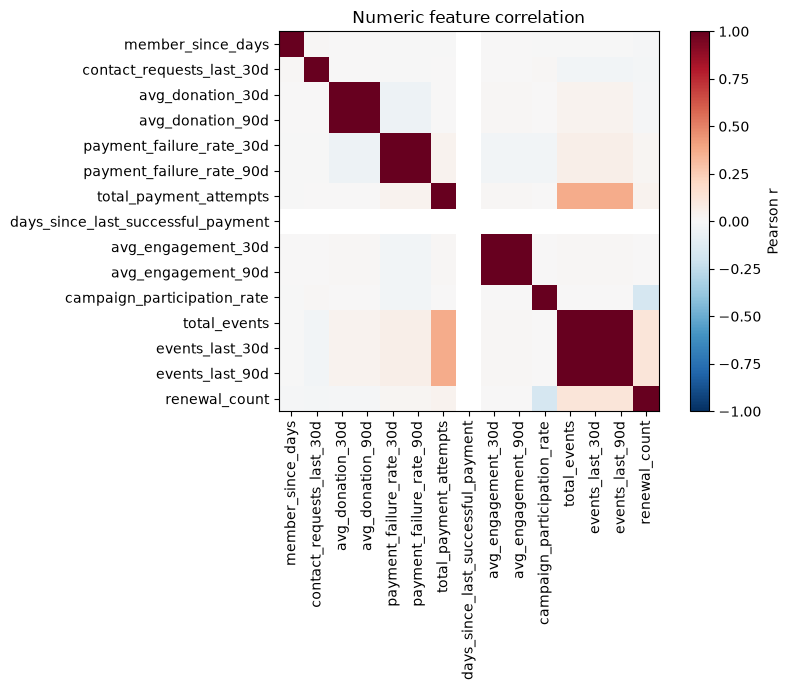

In [23]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label="Pearson r")
plt.title("Numeric feature correlation")
plt.tight_layout()
plt.show()

In [24]:
redundant_pairs = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        r = corr.loc[a, b]
        if abs(r) > 0.7:
            redundant_pairs.append({"feature_a": a, "feature_b": b, "r": r})

redundant_df = pd.DataFrame(redundant_pairs, columns=["feature_a", "feature_b", "r"])
if not redundant_df.empty:
    redundant_df = redundant_df.sort_values("r", key=np.abs, ascending=False)
redundant_df

,feature_a,feature_b,r
0,avg_transaction_30d,avg_transaction_90d,1.0
1,payment_failure_rate_30d,payment_failure_rate_90d,1.0
2,avg_engagement_30d,avg_engagement_90d,1.0
3,total_events,events_last_30d,1.0
4,total_events,events_last_90d,1.0
5,events_last_30d,events_last_90d,1.0


## 4. Baseline model

Trains one lightweight XGBoost model on the full current feature set with class-imbalance weighting (`train_model` derives `scale_pos_weight` from `y`, same as production) and reports PR-AUC as a sanity check — this is not the tuned production model, just confirmation the feature set carries signal at all before spending time on SHAP.

In [25]:
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["churned"],
)
X_train, y_train = prepare_features(train_df)
X_test, y_test = prepare_features(test_df)

baseline_params = {
    "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8,
    "colsample_bytree": 0.8, "n_estimators": 200,
}
fixed_params = {"tree_method": "hist", "enable_categorical": True}

model, feat_names, shap_importance = train_model(
    X_train, y_train, params=baseline_params, fixed_params=fixed_params, random_state=RANDOM_STATE,
)

proba = model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, proba)
print(f"Baseline PR-AUC: {pr_auc:.4f}  (sanity check only — see modeling/hpo.py for the tuned search space)")

Baseline PR-AUC: 0.4955  (sanity check only — see modeling/hpo.py for the tuned search space)


## 5. SHAP importance

Global mean |SHAP| ranks each feature's average impact on the model's output; the beeswarm plot below adds *direction* — whether high values of a feature push predictions toward churn or away from it.

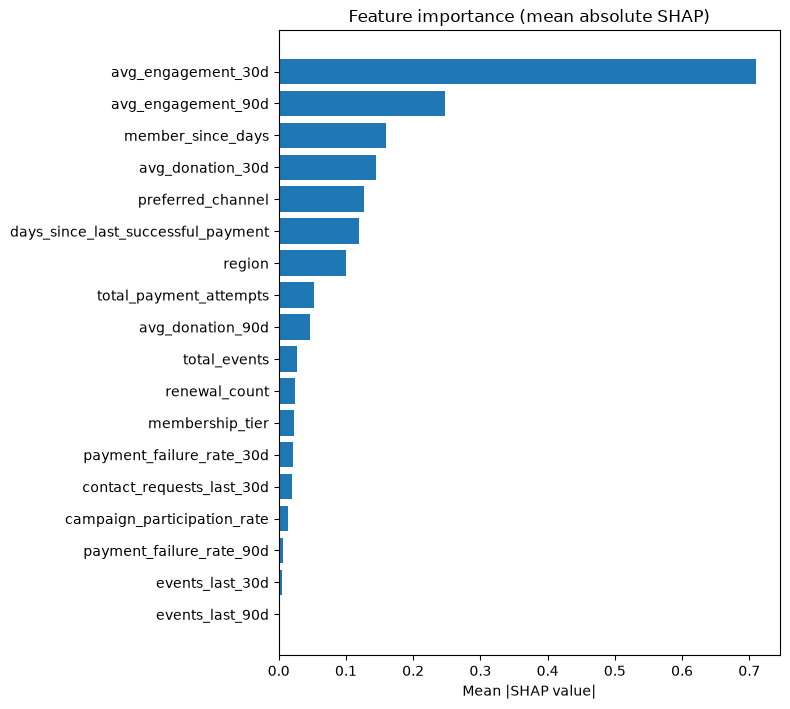

In [26]:
sorted_shap = sorted(shap_importance.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_shap, strict=True)

plt.figure(figsize=(8, len(names) * 0.4))
plt.barh(names[::-1], values[::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Feature importance (mean absolute SHAP)")
plt.tight_layout()
plt.show()

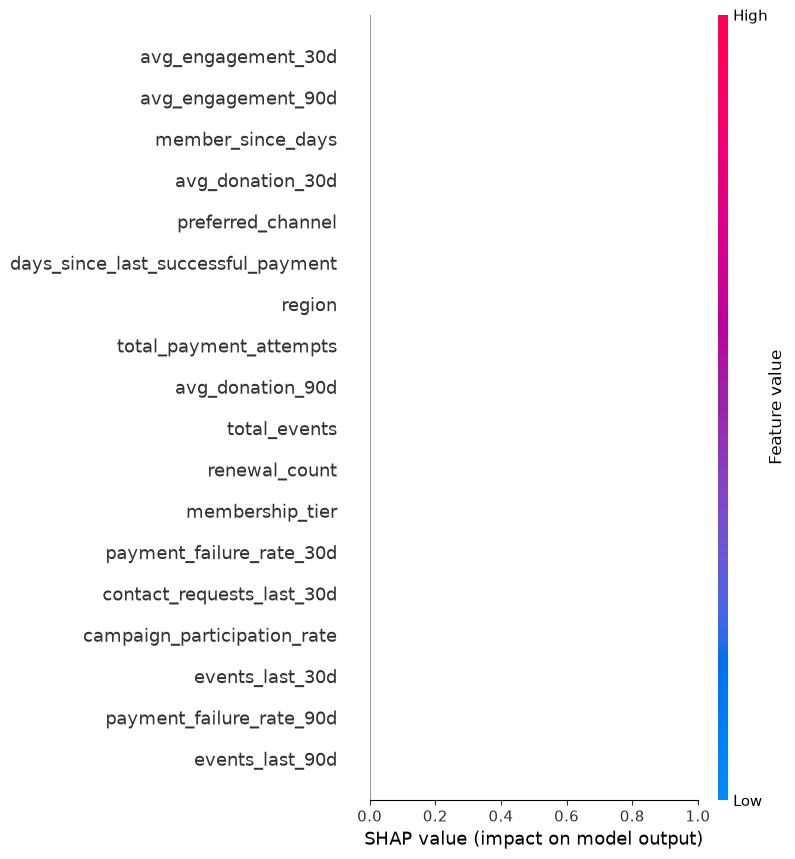

In [27]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="beeswarm", show=True)

## 6. Selection decision

Drop any feature whose mean |SHAP| falls below 5% of the top feature's — but check it against the correlation pairs from step 3 first: if two correlated features both clear the SHAP bar, the lower-ranked one of the pair is still redundant with the higher-ranked one, not independently useful.

In [28]:
max_shap = max(shap_importance.values())
shap_threshold = 0.05 * max_shap

low_importance = {f for f, v in shap_importance.items() if v < shap_threshold}

# Of a correlated pair (|r| > 0.7) that both clear the SHAP bar, keep the higher-SHAP one.
redundant_drops = set()
for _, row in redundant_df.iterrows():
    a, b = row["feature_a"], row["feature_b"]
    if a in low_importance or b in low_importance:
        continue  # already dropping the weaker one on SHAP grounds alone
    loser = a if shap_importance[a] < shap_importance[b] else b
    redundant_drops.add(loser)

to_drop = low_importance | redundant_drops
to_keep = [f for f in feat_names if f not in to_drop]

print(f"Drop ({len(to_drop)}): {sorted(to_drop)}")
print(f"\nKeep ({len(to_keep)}): {to_keep}")

Drop (11): ['avg_transaction_90d', 'avg_engagement_90d', 'campaign_participation_rate', 'contact_requests_last_30d', 'events_last_30d', 'events_last_90d', 'membership_tier', 'payment_failure_rate_30d', 'payment_failure_rate_90d', 'renewal_count', 'total_events']

Keep (7): ['region', 'member_since_days', 'avg_transaction_30d', 'total_payment_attempts', 'days_since_last_successful_payment', 'avg_engagement_30d', 'preferred_channel']


## 7. Production comparison

Compares this run's SHAP ranking against the champion's stored baseline via Spearman rank correlation — the same check the training pipeline's `evaluate` stage runs on every production training run (`post_training.fetch_champion.run_fetch_champion_stage`, keyed off the `role=champion` label and `shap_importance` Model Registry metadata). Running it here surfaces *which* features moved before that 0.75 alert threshold would ever fire (see [docs/feature-exploration.md](../docs/feature-exploration.md), Trigger Signals §2).

In [29]:
from post_training.fetch_champion import run_fetch_champion_stage

_, champion_shap, _ = run_fetch_champion_stage(
    project_id=GCP_PROJECT, region=GCP_REGION, model_display_name=MODEL_DISPLAY_NAME,
)

if champion_shap is None:
    print("No champion registered yet — nothing to compare against.")
else:
    shared = sorted(set(shap_importance) & set(champion_shap))
    current_vals = [shap_importance[f] for f in shared]
    champion_vals = [champion_shap[f] for f in shared]
    rho, p = spearmanr(current_vals, champion_vals)

    print(f"Spearman rank correlation vs. champion baseline: {rho:.3f}")
    if rho < 0.75:
        print("Below the 0.75 alert threshold reported by the pipeline — feature relevance has shifted.")

    delta = pd.DataFrame({
        "feature": shared,
        "current_shap": current_vals,
        "champion_shap": champion_vals,
    })
    delta["rank_current"] = delta["current_shap"].rank(ascending=False)
    delta["rank_champion"] = delta["champion_shap"].rank(ascending=False)
    delta["rank_change"] = delta["rank_champion"] - delta["rank_current"]

    print("\nGained importance:")
    print(delta.sort_values("rank_change", ascending=False).head(3)[["feature", "rank_change"]])
    print("\nLost importance:")
    print(delta.sort_values("rank_change").head(3)[["feature", "rank_change"]])

No champion registered yet — nothing to compare against.


## Output — recommended feature list

In [30]:
print("Recommended features to KEEP:")
for f in to_keep:
    print(f"  - {f}  (mean|SHAP|={shap_importance[f]:.4f})")

print("\nRecommended features to DROP:")
for f in sorted(to_drop):
    reason = "low SHAP" if f in low_importance else "redundant with a higher-SHAP correlated feature"
    print(f"  - {f}  ({reason})")

Recommended features to KEEP:
  - region  (mean|SHAP|=0.0996)
  - member_since_days  (mean|SHAP|=0.1598)
  - avg_transaction_30d  (mean|SHAP|=0.1443)
  - total_payment_attempts  (mean|SHAP|=0.0532)
  - days_since_last_successful_payment  (mean|SHAP|=0.1191)
  - avg_engagement_30d  (mean|SHAP|=0.7102)
  - preferred_channel  (mean|SHAP|=0.1262)

Recommended features to DROP:
  - avg_transaction_90d  (redundant with a higher-SHAP correlated feature)
  - avg_engagement_90d  (redundant with a higher-SHAP correlated feature)
  - campaign_participation_rate  (low SHAP)
  - contact_requests_last_30d  (low SHAP)
  - events_last_30d  (low SHAP)
  - events_last_90d  (low SHAP)
  - membership_tier  (low SHAP)
  - payment_failure_rate_30d  (low SHAP)
  - payment_failure_rate_90d  (low SHAP)
  - renewal_count  (low SHAP)
  - total_events  (low SHAP)


## Next steps / promotion path

If this feature set differs from what's currently in production, propagate it through (see [docs/feature-exploration.md](../docs/feature-exploration.md), Output & Promotion Path):

1. `projects/ml_common/src/ml_common/preprocess.py` — update `CATEGORICAL_COLS`/`DROP_COLS` if a categorical or metadata column changed. The feature *list* itself isn't a separate manifest — it's implicit in the BigQuery schema plus `feature_names()`.
2. `projects/dbt_transform/models/` — add/remove columns from `int_customer_aggregates.sql` and `customer_features.sql`.
3. `iac/config/bigquery.yaml` — add/remove the matching column definitions.
4. `docs/data-lifecycle.md` — update the feature group and schema tables.